# Pretraining the language model on Wikipedia

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [2]:
from lgm import *

## Wikipedia data

In [3]:
# path = URLs.LOCAL_PATH/'data'

In [4]:
# !wget https://s3.amazonaws.com/research.metamind.io/wikitext/wikitext-{version}-v1.zip -P {path}
# !unzip -q -n {path}/wikitext-{version}-v1.zip  -d {path}
# !mv {path}/wikitext-{version}/wiki.train.tokens {path}/wikitext-{version}/train.txt
# !mv {path}/wikitext-{version}/wiki.valid.tokens {path}/wikitext-{version}/valid.txt
# !mv {path}/wikitext-{version}/wiki.test.tokens {path}/wikitext-{version}/test.txt

We split the Wikipedia texts into articles: 

- WT103 is given as one big text file and we need to chunk it in different articles if we want to be able to shuffle them at the beginning of each epoch.

In [5]:
path = URLs.LOCAL_PATH/'data'/'wikitext-103'

In [6]:
def istitle(line):
    return len(re.findall(r'^ = [^=]* = $', line)) != 0

def read_wiki(filename):
    articles = []
    with open(filename, encoding='utf8') as f:
        lines = f.readlines()
    current_article = ''
    for i, line in enumerate(lines):
        current_article += line
        if i < len(lines)-2 and lines[i+1] == ' \n' and istitle(lines[i+2]):
            current_article = current_article.replace('<unk>', UNK)
            articles.append(current_article)
            current_article = ''
    current_article = current_article.replace('<unk>', UNK)
    articles.append(current_article)
    return articles

Create train and validation sets:
- there is a `'test.txt'` set, but we won't worry about it.

In [7]:
train = TextList(read_wiki(path/'train.txt'), path=path)
valid = TextList(read_wiki(path/'valid.txt'), path=path)

In [8]:
len(train), len(valid)

(28476, 60)

In [9]:
# splitdata = SplitData(train, valid)

In [10]:
# proc_tok = TokenizeProcessor()
# proc_num = NumericalizeProcessor()

In [11]:
# labeled_list = label_by_func(splitdata, lambda x: 0, processor_x = [proc_tok, proc_num])

In [12]:
import pickle
# pickle.dump(labeled_list, open(path/'labeled_list_wikipedia.pkl', 'wb'))

In [14]:
labeled_list = pickle.load(open(path/'labeled_list_wikipedia.pkl', 'rb'))

In [15]:
batch_size = 64
bptt = 70
data = lm_databunchify(labeled_list, batch_size, bptt)

In [16]:
vocab = labeled_list.train.processor_x[-1].vocab
len(vocab)

60006

In [17]:
print(vocab[:100])

['_UNK_', '_PAD_', '_BOS_', '_EOS_', '_REP_', '_WREP_', '_ALLCAPS_', '_CAP_', 'the', ',', '.', 'of', 'and', 'in', 'to', 'a', '=', '"', 'was', 'on', '-', "'s", 'as', 'for', 'that', 'with', 'by', '\n ', ')', '(', 'is', '\n \n ', 'his', 'at', 'he', 'it', 'from', '_unk_', 'were', 'an', 'had', 'which', 'be', 'this', 'but', "'", 'are', 'not', 'first', 'their', 'after', ';', 'one', 'her', '–', 'also', 'its', ':', 'they', 'two', 'or', 'have', 'who', 'new', 'been', 'has', '@,@', 'she', 'when', 'time', 'during', 'other', 'would', 'into', 'all', 'more', 'while', 'over', 'i', 'him', 'game', 'only', 'later', 'up', 'most', 'three', 'about', 'out', 'between', 'there', 'than', 'some', 'film', 'may', '1', 'no', 'before', 'made', 'such', 'season']


In [18]:
vocab.index(PAD)

1

## Pretrain AWD-LSTM on Wikipedia

The hyper-params and the model:

In [19]:
# import numpy as np
dropout_probs = np.array([0.1, 0.15, 0.25, 0.02, 0.2]) * 0.2
tok_pad = vocab.index(PAD)
emb_dim = 300
hidden_dim = 300
n_layers = 2 # number of stacked LSTM layers

model = get_language_model(len(vocab), emb_dim, hidden_dim, n_layers, tok_pad, *dropout_probs)

Additional training constraints (gradient clipping and activation regularizations):

In [20]:
callback_funcs = [partial(GradientClipping, clip=0.1),
                  partial(RNNTrainer, alpha=2., beta=1.)]

In [21]:
learn = Learner(model, data, cross_entropy_flat, adam_opt(),
                metrics=accuracy_flat, callback_funcs=callback_funcs)

We find a good learning rate:

epoch,train_loss,train_accuracy_flat,valid_loss,valid_accuracy_flat,time


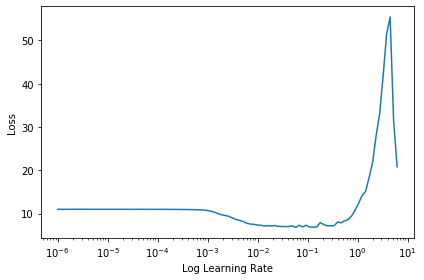

In [22]:
learn.fit(1, callbacks=LRFinder())

We set up the hyper-param scheduler (learning rate and momenta for Adam):

In [23]:
lr = 5e-3
callback_sched = sched_1cycle(lr, pct_start=0.3, mom_start=0.8, mom_mid=0.7, mom_end=0.8)

Finally, we train the language model on Wikipedia:

In [24]:
# learn.fit(1, callbacks=callback_sched)

epoch,train_loss,train_accuracy_flat,valid_loss,valid_accuracy_flat,time
0,4.221921,0.327543,3.887195,0.349111,37:31


In [25]:
# torch.save(learn.model.state_dict(), path/'pretrained.pth')
# pickle.dump(vocab, open(path/'vocab.pkl', 'wb'))

## Pretrain AWD-LSTM on Wikipedia - Colab version

In [26]:
# %load_ext autoreload
# %autoreload 2

# %matplotlib inline
# !pip3 install --upgrade lgm

In [27]:
# from lgm import *

Mounting local drive directory:

In [28]:
# from google.colab import drive
# drive.mount('/content/drive')

In [29]:
# !nvidia-smi

In [30]:
# torch.cuda.get_device_name(torch.cuda.current_device())

In [31]:
# URLs.LOCAL_PATH = Path('/content/drive/My Drive/lgm_colab_exps'); print(URLs.LOCAL_PATH)

In [32]:
# path = URLs.LOCAL_PATH/'data'/'wikitext-103'

In [33]:
# import pickle
# ll = pickle.load(open(path/'labeled_list_wikipedia.pkl', 'rb'))

In [34]:
# bs, bptt = 64, 70
# data = lm_databunchify(ll, bs, bptt)

In [35]:
# vocab = ll.train.processor_x[-1].vocab
# pickle.dump(vocab, open(path/'vocab.pkl', 'wb'))
# len(vocab)

In [36]:
# print(vocab)

In [37]:
# emb_sz, nh, nl = 300, 300, 2
# dps = np.array([0.1, 0.15, 0.25, 0.02, 0.2]) * 0.2
# tok_pad = vocab.index(PAD)

# model = get_language_model(len(vocab), emb_sz, nh, nl, tok_pad, *dps)

In [38]:
# callback_funcs = [partial(GradientClipping, clip=0.1),
#                   partial(RNNTrainer, alpha=2., beta=1.)]

In [39]:
# learn = Learner(model, data, cross_entropy_flat, adam_opt(),
#                 metrics=accuracy_flat, lr=5e-3, callback_funcs=callback_funcs,
#                 model_name='pretrained_colab')

In [40]:
# learn.model.load_state_dict(torch.load(URLs.LOCAL_PATH/'pretrained_colab_final_1.pth'))

In [41]:
# learn.fit(1, callbacks=LRFinder())

In [42]:
# lr = 5e-3
# hyper_sched = sched_1cycle(lr, pct_start=0.3, mom_start=0.8, mom_mid=0.7, mom_end=0.8)

In [43]:
# learn.fit(3, callbacks=hyper_sched)

In [44]:
# torch.save(learn.model.state_dict(), URLs.LOCAL_PATH/'pretrained_colab_final_1.pth')

In [45]:
# learn.plotter.plot_train_stats()

In [46]:
# learn.plotter.plot_valid_stats()

In [47]:
# learn.plotter.plot_lr()